In [3]:
import time 
import random
from pathlib import Path 

import cv2 
import numpy as np
import pandas as pd
from tqdm.auto import tqdm 
from deepface import DeepFace
import IPython

/tmp/ipykernel_469155/2881874155.py:7: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
2024-02-22 19:12:18.650905: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-22 19:12:18.650933: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-22 19:12:18.651930: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable

In [4]:
def test_backends_images(frames,
                         backends = [
                            "opencv",
                            "mtcnn",
                            "ssd",
                            "dlib",
                            "retinaface",
                            "yunet",
                            "fastmtcnn"
                        ],
                        pivot=True,
                        enforce_detection=False,
                        exists=False):
    if isinstance(frames[0], str):
        frames = [cv2.imread(x) for x in frames]

    data = []
    for backend in tqdm(backends):
        for num, image in enumerate(frames):
            t = time.time()
            try:
                results = DeepFace.extract_faces(image, 
                                                 detector_backend=backend,
                                                 enforce_detection=enforce_detection)
            except:
                datum = {'confidence': np.nan,
                         'duration': time.time() - t,
                         'model': backend,
                         'img_num': num,
                         'face_num': np.nan}
                data.append(datum)
                continue
            
            d = time.time() - t
            for face_num, result in enumerate(results):
                datum = {k:v for k, v in {**result}.items() if k not in ['facial_area', 'face']}
                datum['duration'] = d
                datum['model'] = backend
                datum['confidence'] = float(datum['confidence'])
                datum['img_num'] = num
                datum['face_num'] = face_num
                data.append(datum)
    df = pd.DataFrame(data)
    if pivot:
        table = pd.pivot_table(df, 
                            values=['confidence', 'duration', 'face_num'],
                            index=['model'],
                            columns=['img_num'],
                            aggfunc={'confidence': 'mean', 
                                        'duration': 'mean',
                                        'face_num': 'count'},
                                margins=True)
        return frames, table.stack('img_num')
    else:
        g = df.drop('img_num', axis=1).groupby('model').agg({'confidence': 'mean',
                                                             'duration': 'mean',
                                                             'face_num': 'count' if exists else lambda x: 1 if np.sum([1 if not pd.isnull(i) else 0 for i in x]) > 0 else 0})
        return frames, g

In [5]:
def test_backends_video(src='/home/amos/test.mkv', pivot=True, k=10, return_frames=False):
    cap = cv2.VideoCapture(src)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    sample_frames = [x for x in random.sample([x for x in range(frame_count)], k=k)]
    frames = []
    for sample_frame in sample_frames:
        cap.set(cv2.CAP_PROP_POS_FRAMES, sample_frame)
        _, frame = cap.read()
        if frame is None:
            continue
        frames.append(frame)
    frames, df = test_backends_images(frames, pivot=pivot)
    return (frames, df) if return_frames else df 

In [6]:
def test_models(frames,
                models = [
                    'VGG-Face',
                    'Facenet',
                    'Facenet512',
                    'OpenFace',
                    'DeepFace',
                    'DeepID',
                    'Dlib',
                    'ArcFace',
                    'SFace'
                            ]):
    if isinstance(frames[0], str):
        images = [cv2.imread(x) for x in frames]
    else:
        images = frames
    data = []
    for model_name in tqdm(models):
        for num, img in enumerate(images):
            t = time.time()
            results = DeepFace.represent(img, model_name=model_name, enforce_detection=False)
            for n, result in enumerate(results):
                datum = {**result}
                datum['duration'] = time.time() - t
                datum['model'] = model_name
                datum['img_num'] = num
                datum['face_num'] = n
                data.append(datum)
    df = pd.DataFrame(data)
    df = df[['model', 'duration', 'face_num']]
    g = df.groupby('model').agg({'duration': 'mean', 'face_num': 'count'})
    return g

In [7]:
def show_image(src):
    if isinstance(src, str):
        img = cv2.imread(src)
    else:
        img = src
    _, ret = cv2.imencode('.jpg', img)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [8]:
images = ['/home/amos/img_1.jpg',
          '/home/amos/img_2.jpg',
          '/home/amos/img_3.jpg',
          '/home/amos/img_4.jpg']

In [9]:
test_images = [str(x) for x in Path('/home/amos/datasets/CineFace/images/1442437').iterdir()][:10]

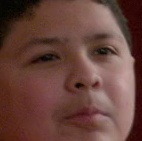

In [10]:
src = test_images[0]
img = cv2.imread(src)
_, ret = cv2.imencode('.jpg', img)
i = IPython.display.Image(data=ret)
IPython.display.display(i)


In [196]:
%%capture
frames, df = test_backends_images(images, pivot=False, enforce_detection=True, exists=True)

In [197]:
df

,confidence,duration,face_num
model,,,
dlib,1.523853,0.162951,57
fastmtcnn,0.997691,0.292496,66
mtcnn,0.998140,0.763707,67
opencv,7.308385,0.079590,59
retinaface,0.996332,1.316463,67
ssd,0.968251,0.037049,11
yunet,0.921786,0.015790,56


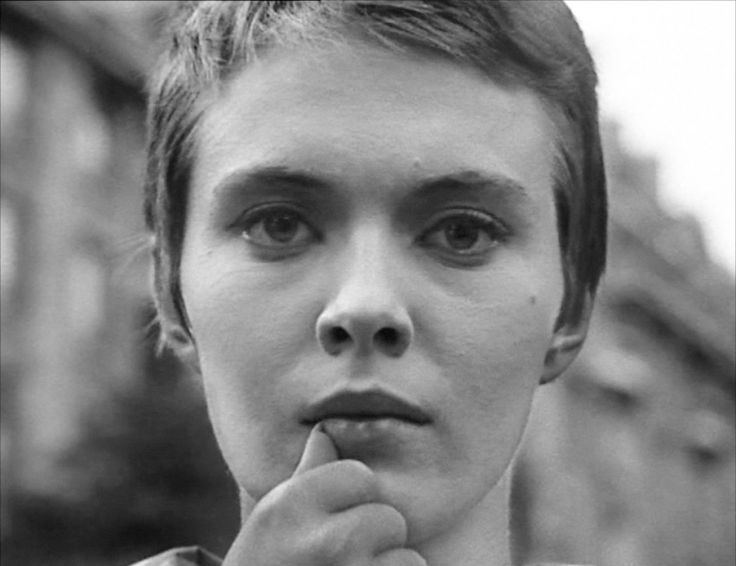

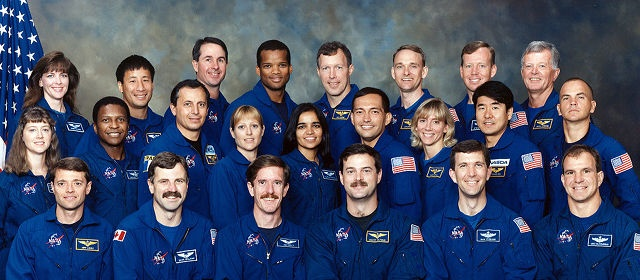

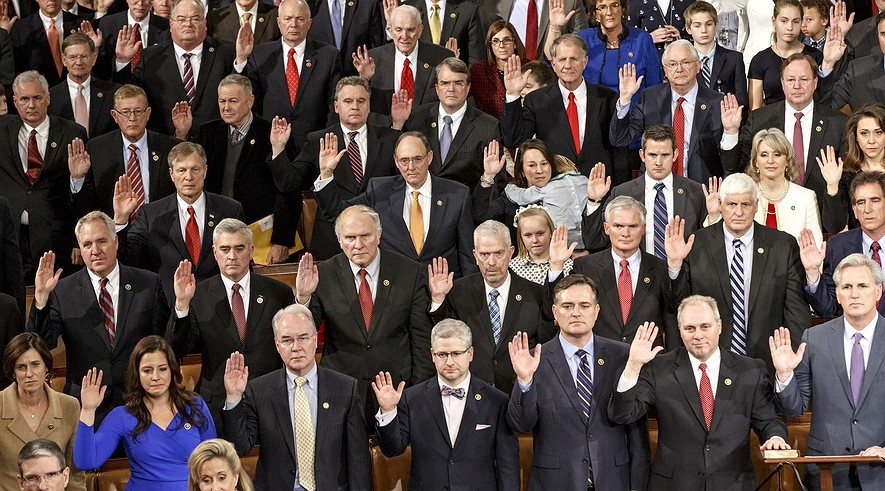

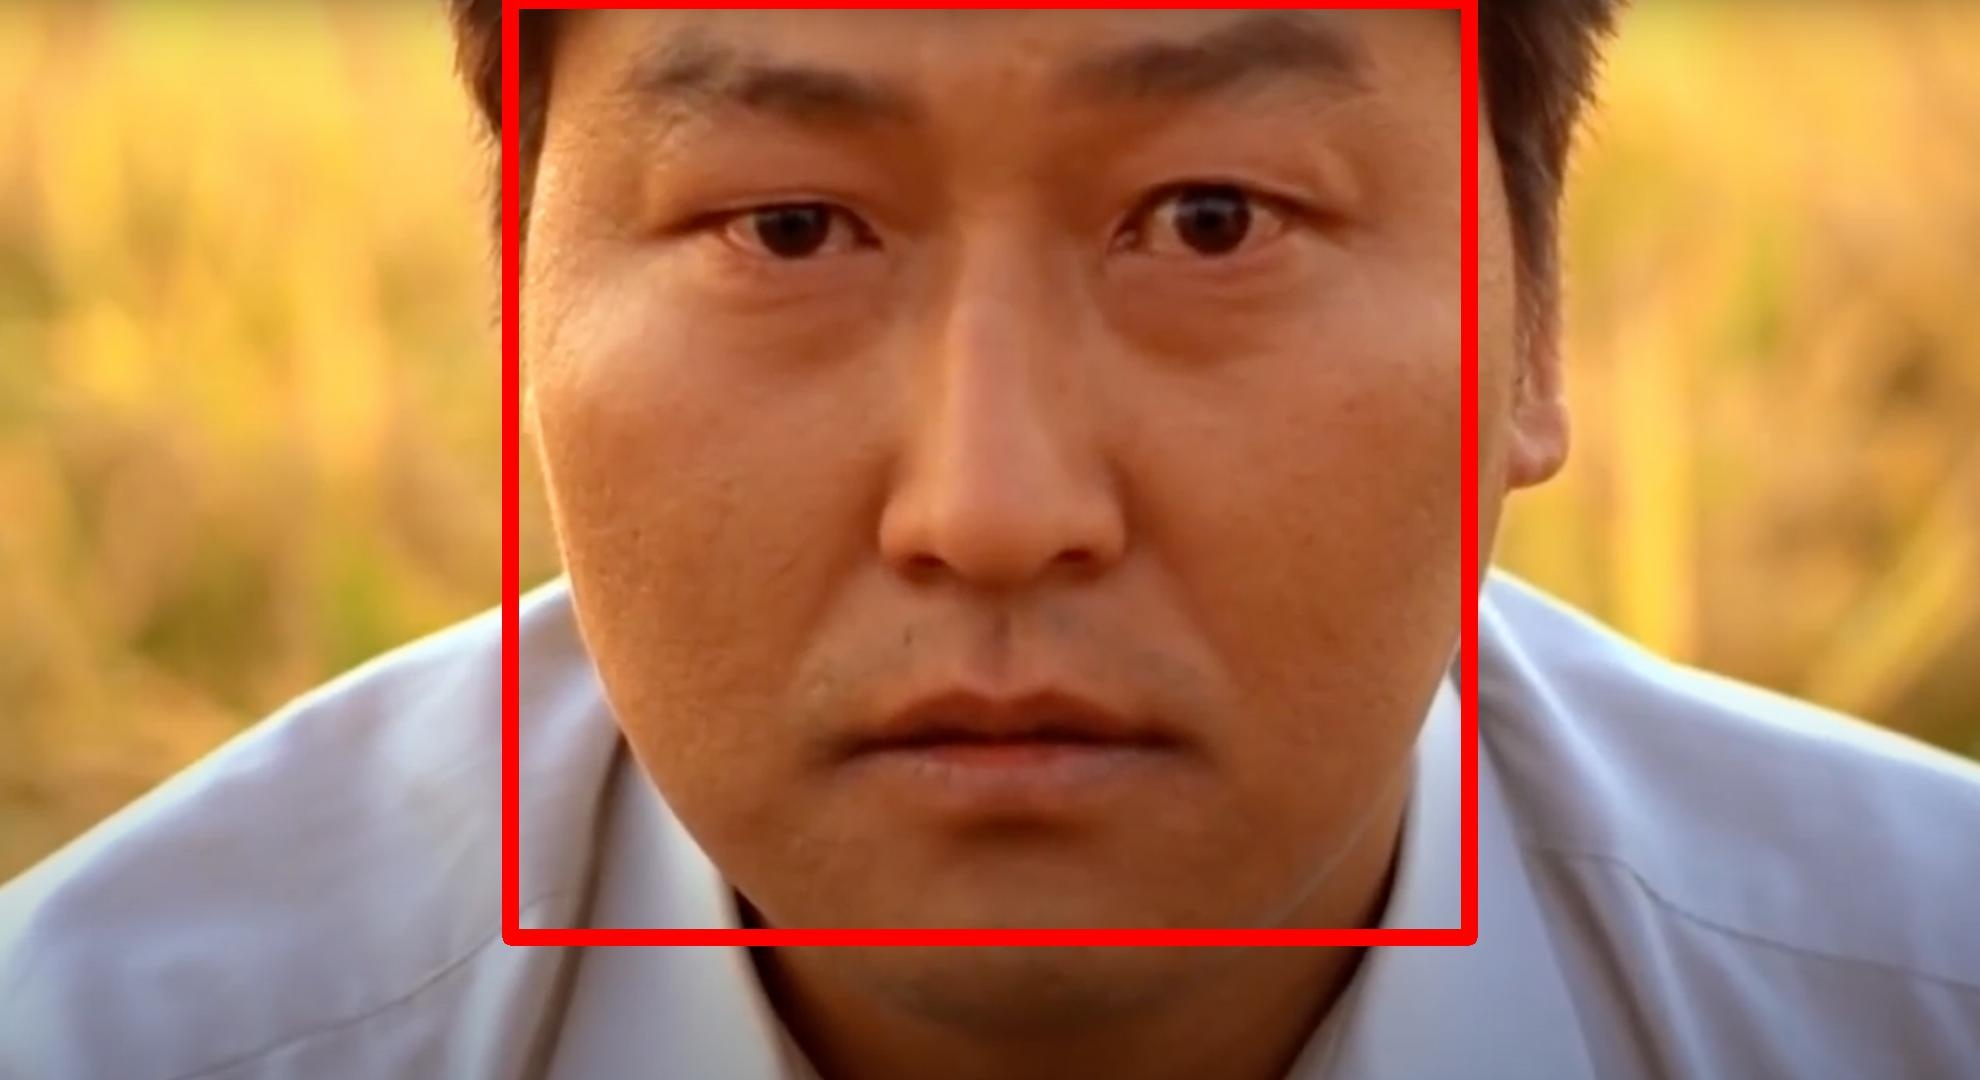

In [198]:
for frame in frames:
    show_image(frame)

In [204]:
%%capture
df = test_models(test_images)

In [205]:
df

,duration,face_num
model,,
ArcFace,0.107495,10
DeepFace,1.294524,10
DeepID,0.011197,10
Dlib,0.083092,10
Facenet,0.163480,10
Facenet512,0.164590,10
OpenFace,0.061913,10
SFace,0.013583,10
VGG-Face,0.128683,10


In [210]:
%%capture
df = test_backends_video(k=385, pivot=False)

[h264 @ 0x4f30fb00] mmco: unref short failure
[h264 @ 0x4f30fb00] mmco: unref short failure
[h264 @ 0x4f30fb00] mmco: unref short failure
[h264 @ 0x4f30fb00] mmco: unref short failure
[h264 @ 0x4f30fb00] mmco: unref short failure
[h264 @ 0x4f30fb00] mmco: unref short failure
[h264 @ 0x4f30fb00] mmco: unref short failure
[h264 @ 0x4f30fb00] mmco: unref short failure
[h264 @ 0x4f30fb00] mmco: unref short failure
[h264 @ 0x4f30fb00] mmco: unref short failure
[h264 @ 0x4f30fb00] mmco: unref short failure
[h264 @ 0x4f30fb00] mmco: unref short failure
[h264 @ 0x4f30fb00] mmco: unref short failure
[h264 @ 0x4f30fb00] mmco: unref short failure
[h264 @ 0x4f30fb00] mmco: unref short failure
[h264 @ 0x4f30fb00] mmco: unref short failure
[h264 @ 0x4f30fb00] mmco: unref short failure
[h264 @ 0x4f30fb00] number of reference frames (0+4) exceeds max (3; probably corrupt input), discarding one
[h264 @ 0x4f30fb00] mmco: unref short failure
[h264 @ 0x4f30fb00] mmco: unref short failure
[h264 @ 0x4f30fb0

In [211]:
df 

,confidence,duration,face_num
model,,,
dlib,0.217533,0.803180,1
fastmtcnn,0.952560,0.233299,1
mtcnn,0.624634,1.055312,1
opencv,1.639399,0.105383,1
retinaface,0.667525,1.332059,1
ssd,0.284720,0.023035,1
yunet,0.260806,0.010843,1


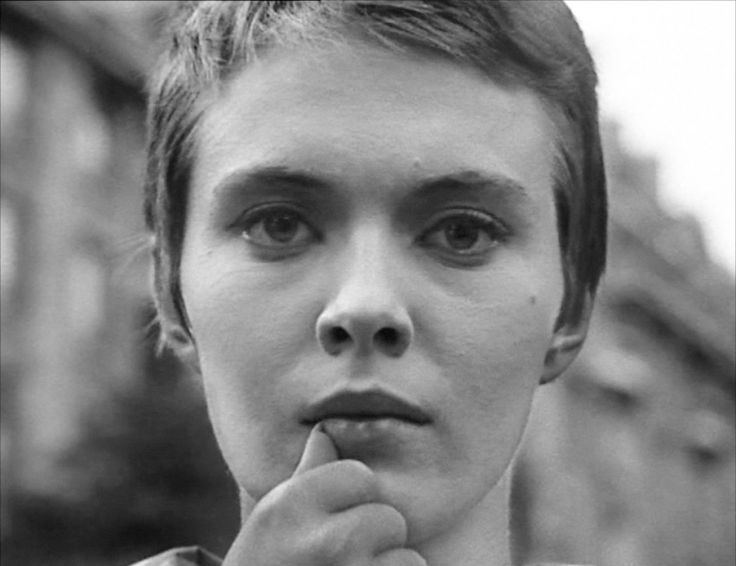

In [11]:
show_image(images[0])

In [13]:
r = DeepFace.represent(images[0], model_name='DeepID')

In [14]:
r

[{'embedding': [0.0,
   0.0,
   20.736955642700195,
   50.223392486572266,
   0.0,
   0.0,
   45.83108901977539,
   0.0,
   0.0,
   0.0,
   4.1297478675842285,
   3.288306474685669,
   25.00893783569336,
   0.0,
   0.0,
   0.0,
   0.0,
   9.716780662536621,
   13.393421173095703,
   0.0,
   1.6314067840576172,
   0.0,
   0.0,
   30.659799575805664,
   0.0,
   17.403963088989258,
   0.0,
   0.0,
   0.0,
   0.0,
   2.7049448490142822,
   32.74179458618164,
   20.59695816040039,
   25.188426971435547,
   22.929012298583984,
   0.0,
   27.14147186279297,
   4.43414831161499,
   8.130348205566406,
   43.8717041015625,
   0.0,
   20.497234344482422,
   14.496255874633789,
   0.0,
   17.165014266967773,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   14.289260864257812,
   0.0,
   0.0,
   7.86772346496582,
   0.0,
   0.0,
   22.54401397705078,
   0.0,
   0.0,
   24.567188262939453,
   38.35788345336914,
   14.551780700683594,
   3.1642303466796875,
   38.82359313964844,
   0.0,
   0.0,
   8.548666

In [18]:
len(r[0]['embedding'])

160